In [1]:
import sys
sys.path.append("..")

import torch

from source.system import SystemParams
from source.policy import NeuralPolicy
from source.utils import read_csv

from source.training import train_net

import matplotlib.pyplot as plt

plt.style.use("../styles/paper.mplstyle")

from source.diagnostics import check_energy_balance

from source.stochastic_processes import make_price_function
from source.simulation import rollout_trajectory
from source.plotting import (
    plot_state_trajectories,
    plot_control_trajectories,
    plot_endogenous_trajectories,
    plot_cost_trajectories,
)

In [2]:
EPOCHS = 20
BATCH_SIZE = 32

DEVICE = torch.device("cpu")

params = SystemParams()

S0_single = torch.tensor([[0., 0., 100., 0.01]], device=DEVICE)

energy_prices = read_csv("../data/eprice_test.csv")

price_history = energy_prices[:24]
future_price = energy_prices[24:]

policy = NeuralPolicy().to(DEVICE)

optimizer = torch.optim.AdamW(
    policy.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

res = train_net(
    policy=policy,
    optimizer=optimizer,
    device=DEVICE,
    params=params,
    S0_single=S0_single,
    endog_history=price_history,
    future_endog=future_price,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=True
)

[001] J_train=-6.8555 | J_eval(det)=-7.1452
[002] J_train=-7.2107 | J_eval(det)=-7.2544
[003] J_train=-7.1500 | J_eval(det)=-7.3634
[004] J_train=-7.2542 | J_eval(det)=-7.4716
[005] J_train=-7.6242 | J_eval(det)=-7.5783
[006] J_train=-7.4610 | J_eval(det)=-7.6856
[007] J_train=-7.8259 | J_eval(det)=-7.7938
[008] J_train=-7.7550 | J_eval(det)=-7.9037
[009] J_train=-7.8019 | J_eval(det)=-8.0145
[010] J_train=-7.8435 | J_eval(det)=-8.1264
[011] J_train=-7.9031 | J_eval(det)=-8.2384
[012] J_train=-8.3173 | J_eval(det)=-8.3481
[013] J_train=-8.3795 | J_eval(det)=-8.4544
[014] J_train=-8.3138 | J_eval(det)=-8.5640
[015] J_train=-8.5075 | J_eval(det)=-8.6676
[016] J_train=-8.4030 | J_eval(det)=-8.7699
[017] J_train=-8.8357 | J_eval(det)=-8.8707
[018] J_train=-8.9483 | J_eval(det)=-8.9653
[019] J_train=-9.1814 | J_eval(det)=-9.0562
[020] J_train=-8.8913 | J_eval(det)=-9.1477

Training ready in 14.4s. Epoch: 19. Best J=-9.1814


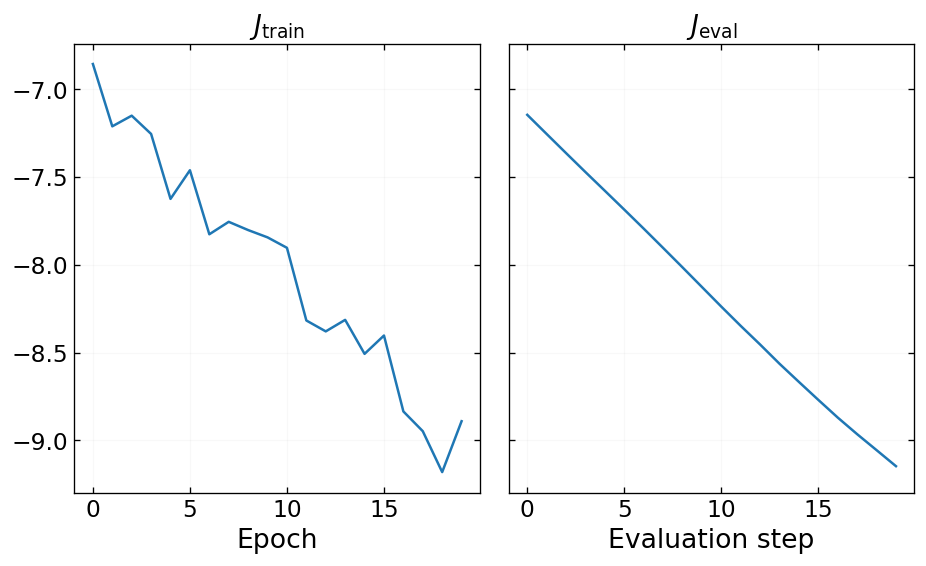

In [3]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True)

ax[0].plot(res["J_train_hist"])
ax[0].set_title(r"$J_{\mathrm{train}}$")
ax[0].set_xlabel("Epoch")

ax[1].plot(res["J_eval_hist"])
ax[1].set_title(r"$J_{\mathrm{eval}}$")
ax[1].set_xlabel("Evaluation step")

plt.tight_layout()
plt.show()

In [4]:
next_price_fn = make_price_function(price_history, future_price, params)

S0_demo = S0_single.repeat(20, 1)

t_hist, S_hist, endog_hist, u_hist, A_hist, B_hist, c_hist, J_episode = rollout_trajectory(
    policy=policy,
    S0=S0_demo,
    params=params,
    next_price_fn=next_price_fn,
    stochastic=True,
    seed=1,
    device=DEVICE,
)

print(f"Demo rollout J: {J_episode:.4f}")

Demo rollout J: -9.1631


In [5]:
check_energy_balance(endog_hist, dt=params.dt)

{'max_abs_error': 9.313225746154785e-10,
 'mean_abs_error': 9.50329116615467e-13,
 'mean_Ub': 16.864511489868164,
 'max_Ub': 117.55667114257812}

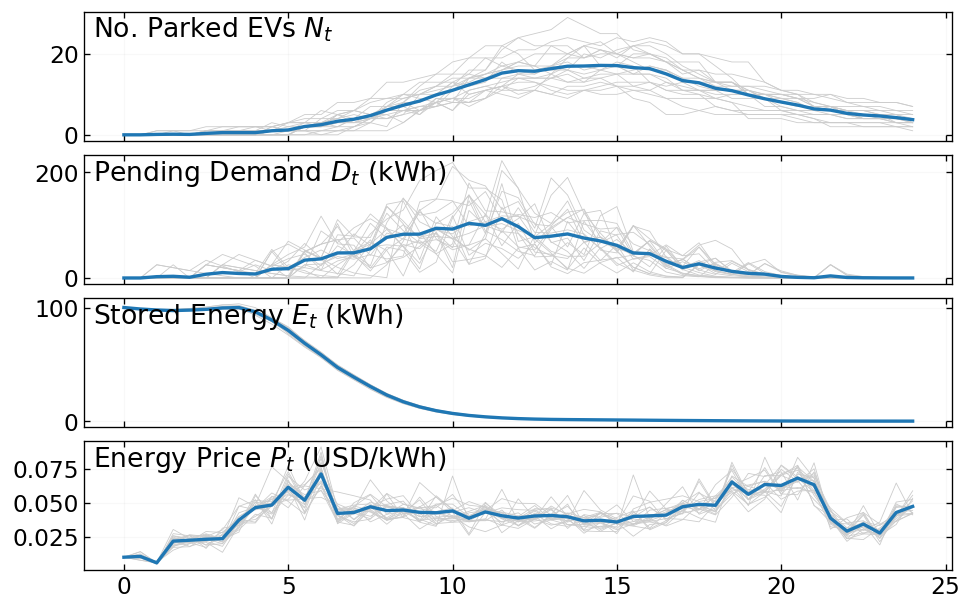

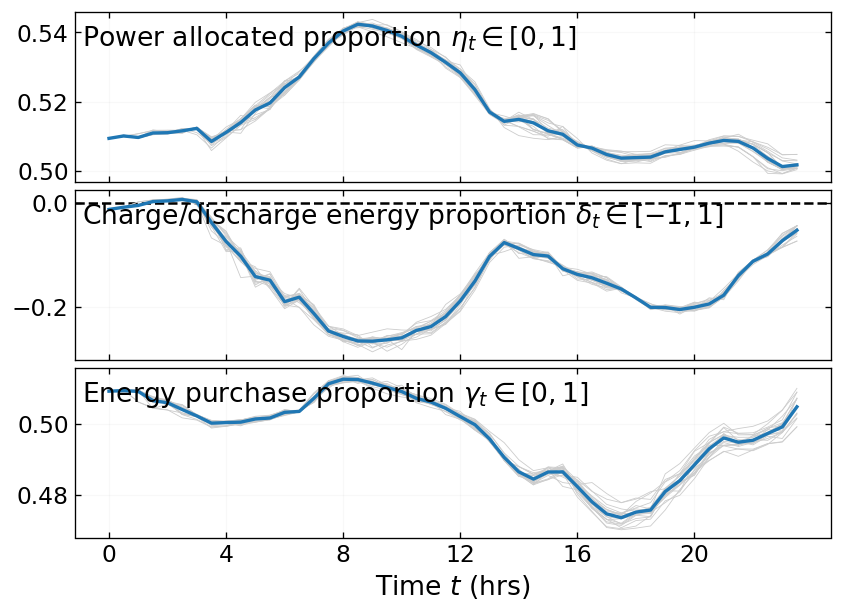

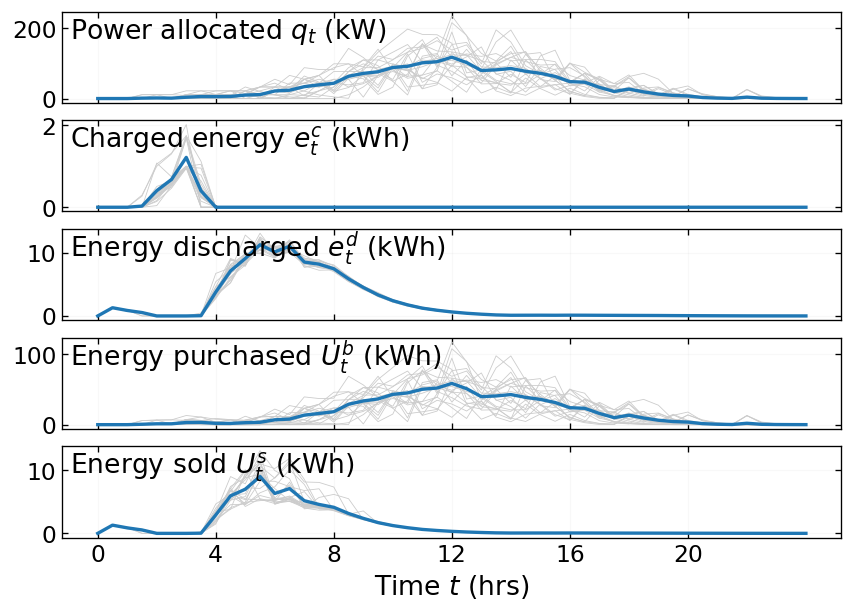

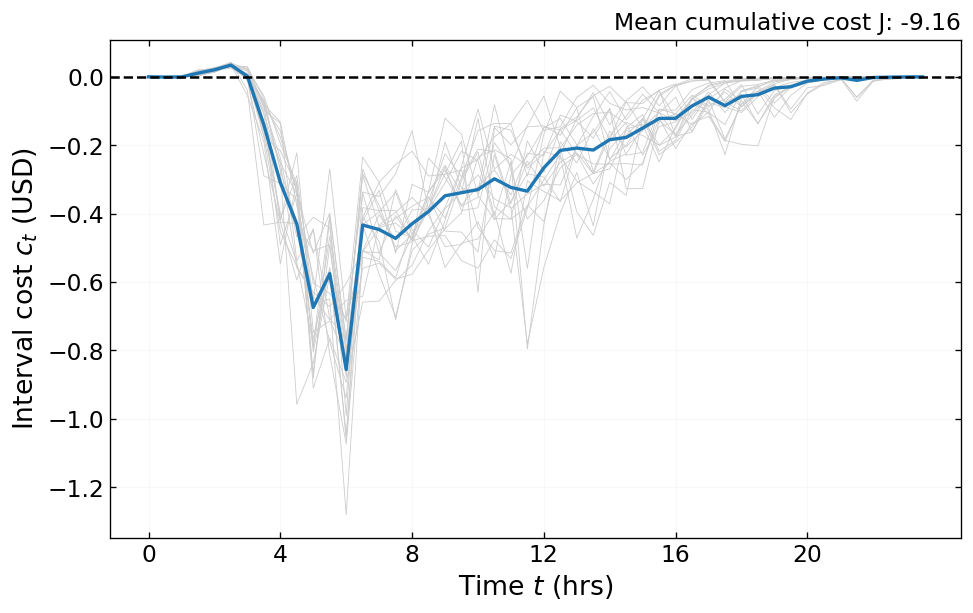

In [6]:
plot_state_trajectories(t_hist, S_hist)
plot_control_trajectories(t_hist, u_hist)
plot_endogenous_trajectories(t_hist, endog_hist)
plot_cost_trajectories(t_hist, c_hist, J_episode)